# Comparing Eye-Movement Patterns

When you study an image, you move your eyes to different locations in a
particular sequence. If you later see that same image during a memory test, do
you look at the same places? This kind of "eye-movement reinstatement" is a
powerful marker of memory, and `peyesim` gives you the tools to measure it.

This notebook walks you through the core workflow: representing fixations,
computing density maps, and measuring similarity between fixation patterns
across experimental conditions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from peyesim import (
    fixation_group, eye_density, similarity,
    eye_table, density_by, template_similarity,
    sample_density_time,
)

## How do you represent fixations?

A `fixation_group` holds a set of eye fixations — each defined by an x/y
screen position, an onset time (when the fixation began), and a duration (how
long the eye stayed there). You can create one directly:

In [2]:
fg = fixation_group(
    x=[-100, 0, 100],
    y=[0, 100, 0],
    onset=[0, 10, 60],
    duration=[10, 50, 100],
)
fg.to_pandas()

,index_col,x,y,duration,onset,group_index
0,1,-100.0,0.0,10.0,0.0,0
1,2,0.0,100.0,50.0,10.0,0
2,3,100.0,0.0,100.0,60.0,0


Here is a more realistic group with 25 randomly placed fixations:

In [3]:
rng = np.random.default_rng(42)
fg = fixation_group(
    x=rng.uniform(0, 100, 25),
    y=rng.uniform(0, 100, 25),
    onset=np.cumsum(rng.uniform(0, 100, 25)),
    duration=rng.uniform(50, 300, 25),
)
fg.to_pandas().head()

,index_col,x,y,duration,onset,group_index
0,1,77.395605,19.463871,120.345973,19.990820,0
1,2,43.887844,46.672100,123.398439,20.727047,0
2,3,85.859792,4.380377,215.479129,99.419485,0
3,4,69.736803,15.428949,189.258038,165.904571,0
4,5,9.417735,68.304895,245.974552,236.421108,0


## How do you visualize fixation density?

Individual points can be hard to interpret. Density maps show you where
fixations cluster. Convert a fixation group into an `EyeDensity` and
plot it as a heatmap:

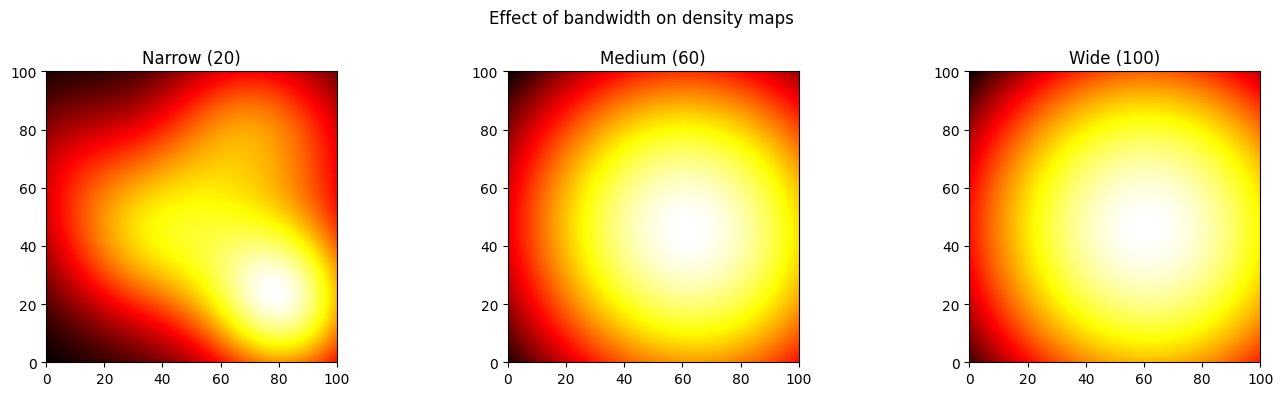

In [4]:
ed = eye_density(fg, sigma=35, xbounds=(0, 100), ybounds=(0, 100))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, bw, title in zip(axes, [20, 60, 100], ["Narrow (20)", "Medium (60)", "Wide (100)"]):
    d = eye_density(fg, sigma=bw, xbounds=(0, 100), ybounds=(0, 100))
    ax.imshow(d.z.T, origin="lower", extent=[d.x.min(), d.x.max(), d.y.min(), d.y.max()], cmap="hot")
    ax.set_title(title)
plt.suptitle("Effect of bandwidth on density maps")
plt.tight_layout()
plt.show()

## How do you compare two fixation patterns?

To quantify how similar two fixation patterns are, convert them to
`EyeDensity` maps and call `similarity()`. Here we create two patterns that
share roughly half their fixation locations:

In [5]:
rng = np.random.default_rng(123)
x_shared = rng.uniform(0, 100, 12)
y_shared = rng.uniform(0, 100, 12)

fg1 = fixation_group(
    x=np.concatenate([x_shared, rng.uniform(0, 100, 13)]),
    y=np.concatenate([y_shared, rng.uniform(0, 100, 13)]),
    onset=np.cumsum(rng.uniform(0, 100, 25)),
    duration=rng.uniform(50, 300, 25),
)

fg2 = fixation_group(
    x=np.concatenate([x_shared, rng.uniform(0, 100, 13)]),
    y=np.concatenate([y_shared, rng.uniform(0, 100, 13)]),
    onset=np.cumsum(rng.uniform(0, 100, 25)),
    duration=rng.uniform(50, 300, 25),
)

In [6]:
ed1 = eye_density(fg1, sigma=50, xbounds=(0, 100), ybounds=(0, 100))
ed2 = eye_density(fg2, sigma=50, xbounds=(0, 100), ybounds=(0, 100))

print("Pearson similarity:", similarity(ed1, ed2, method="pearson"))

Pearson similarity: 0.9045066781852293


Several similarity methods are available:

In [7]:
methods = ["pearson", "spearman", "fisherz", "cosine", "l1", "jaccard", "dcov"]
results = {m: similarity(ed1, ed2, method=m) for m in methods}
pd.DataFrame({"method": methods, "similarity": [round(results[m], 4) for m in methods]})

,method,similarity
0,pearson,0.9045
1,spearman,0.9020
2,fisherz,1.4965
3,cosine,0.9977
4,l1,0.9716
5,jaccard,0.9447
6,dcov,0.8777


## How do you analyze a full experiment?

In a typical memory study, participants view images during encoding and again
during retrieval. You want to compare fixation patterns between these phases
for the same image and control for non-specific similarity.

Let's simulate a small experiment: 3 participants, 20 images, encoding +
retrieval.

In [8]:
rng = np.random.default_rng(99)

def gen_fixations(imname, phase, participant, rng):
    nfix = rng.integers(3, 11)
    return pd.DataFrame({
        "x": rng.uniform(0, 100, nfix),
        "y": rng.uniform(0, 100, nfix),
        "onset": np.cumsum(rng.uniform(50, 200, nfix)),
        "duration": rng.uniform(100, 400, nfix),
        "image": imname,
        "phase": phase,
        "participant": participant,
    })

rows = []
for s in ["s1", "s2", "s3"]:
    for p in ["encoding", "retrieval"]:
        for img in [f"img{i}" for i in range(1, 21)]:
            rows.append(gen_fixations(img, p, s, rng))

df = pd.concat(rows, ignore_index=True)
print(f"Rows: {len(df)} | Participants: {df['participant'].nunique()} | Images: {df['image'].nunique()}")
df.head()

Rows: 777 | Participants: 3 | Images: 20


,x,y,onset,duration,image,phase,participant
0,56.509163,24.588538,155.388672,120.690215,img1,encoding,s1
1,51.191596,30.943834,273.226565,175.613708,img1,encoding,s1
2,97.218637,39.107965,456.705249,128.557851,img1,encoding,s1
3,61.490314,27.027173,571.970253,133.938810,img1,encoding,s1
4,56.828350,35.001495,715.504223,184.175750,img1,encoding,s1


Wrap the raw data in an `EyeTable`, which groups fixations by the variables
that define your experimental design:

In [9]:
eyetab = eye_table(
    "x", "y", "duration", "onset",
    groupvar=["participant", "phase", "image"],
    data=df,
)
print(eyetab)

EyeTable: 120 groups, 777 total fixations
  origin: (640.0, 640.0)



### Computing density maps by group

`density_by()` computes a density map for every combination of your grouping
variables:

In [10]:
eyedens = density_by(
    eyetab,
    groups=["phase", "image", "participant"],
    sigma=100,
    xbounds=(0, 100),
    ybounds=(0, 100),
)
eyedens.drop(columns=["density", "fixgroup"], errors="ignore").head()

,phase,image,participant
0,encoding,img1,s1
1,encoding,img1,s2
2,encoding,img1,s3
3,encoding,img10,s1
4,encoding,img10,s2


### Template similarity analysis

`template_similarity()` compares each retrieval density map to its matched
encoding density map. It estimates a baseline by permuting image labels and
reports the corrected difference:

In [11]:
enc_dens = eyedens[eyedens["phase"] == "encoding"].reset_index(drop=True)
ret_dens = eyedens[eyedens["phase"] == "retrieval"].reset_index(drop=True)

simres = template_similarity(
    enc_dens, ret_dens,
    match_on="image",
    method="fisherz",
    permutations=50,
)
simres.drop(columns=["density", "fixgroup"], errors="ignore").head()

,phase,image,participant,eye_sim,perm_sim,eye_sim_diff
0,retrieval,img1,s1,0.955768,0.479710,0.476057
1,retrieval,img1,s2,1.363966,0.504353,0.859613
2,retrieval,img1,s3,0.453673,0.797424,-0.343751
3,retrieval,img10,s1,0.381337,0.520955,-0.139618
4,retrieval,img10,s2,2.255666,1.436515,0.819150


The result includes three key columns:

- `eye_sim` — raw similarity between matched pairs
- `perm_sim` — average similarity across non-matching pairs (baseline)
- `eye_sim_diff` — the corrected score (raw minus baseline)

Since our data is random, there should be no true reinstatement:

In [12]:
from scipy import stats

t_result = stats.ttest_1samp(simres["eye_sim_diff"].dropna(), 0)
print(f"t = {t_result.statistic:.3f}, p = {t_result.pvalue:.3f}")

t = 1.295, p = 0.200


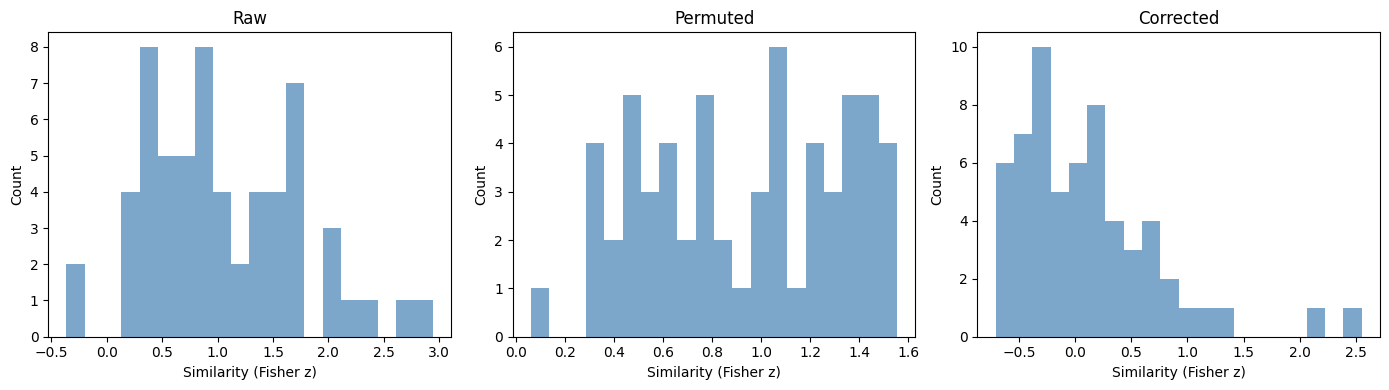

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes,
    ["eye_sim", "perm_sim", "eye_sim_diff"],
    ["Raw", "Permuted", "Corrected"]):
    ax.hist(simres[col].dropna(), bins=20, color="steelblue", alpha=0.7)
    ax.set_xlabel("Similarity (Fisher z)")
    ax.set_ylabel("Count")
    ax.set_title(label)
plt.tight_layout()
plt.show()

As expected, the corrected similarity is centered near zero.

**A note on units.** With `method="fisherz"`, all similarity values are
Fisher z scores (atanh of Pearson r). Convert back to correlations with
`np.tanh()` if desired. With `method="pearson"` or `"spearman"`, values are
correlations directly.

**A note on permutations.** The `permutations` argument is an upper bound. If
fewer non-matching candidates are available, `peyesim` uses all of them
exhaustively.

## What about multiscale analysis?

Choosing a single bandwidth is somewhat arbitrary. You can compute density at
multiple scales by passing a list of sigma values:

In [14]:
eyedens_multi = density_by(
    eyetab,
    groups=["phase", "image", "participant"],
    sigma=[25, 50, 100],
    xbounds=(0, 100),
    ybounds=(0, 100),
)

enc_multi = eyedens_multi[eyedens_multi["phase"] == "encoding"].reset_index(drop=True)
ret_multi = eyedens_multi[eyedens_multi["phase"] == "retrieval"].reset_index(drop=True)

simres_multi = template_similarity(
    enc_multi, ret_multi,
    match_on="image",
    method="fisherz",
    permutations=50,
)

print(f"Single-scale mean: {simres['eye_sim_diff'].mean():.4f}")
print(f"Multiscale mean:   {simres_multi['eye_sim_diff'].mean():.4f}")

Single-scale mean: 0.1068
Multiscale mean:   0.1093


Multiscale analysis provides a more robust similarity estimate by averaging
across spatial resolutions.

## What's next?

- [MultiMatch](02_multimatch.ipynb) — compare scanpath structure across five dimensions
- [Repetitive Similarity](03_repetitive_similarity.ipynb) — analyze repeated viewing of the same stimulus
- [Latent Transforms](04_latent_transforms.ipynb) — domain adaptation for cross-device or cross-participant comparisons